In [1]:
import duckdb
import pandas as pd

# Hubungkan ke database hasil dbt
con = duckdb.connect('../data/ecommerce.db')

# Ambil data dari tabel mart_rfm_analysis
df = con.sql("SELECT * FROM mart_rfm_analysis").df()

con.close()

# Tampilkan 5 data teratas
print(df.head())

                 customer_unique_id  recency_days  frequency  monetary_value  \
0  317cfc692e3f86c45c95697c61c853a6             4          1            9.59   
1  bd06ce0e06ad77a7f681f1a4960a3cc6           350          1           10.07   
2  b33336f46234b24a613ad9064d13106d            69          1           10.89   
3  6f5b9d1cdccc4d28f0483a612edecacf           361          1           11.63   
4  2878e5b88167faab17d4fb83a986d38b           304          1           11.63   

   r_score  f_score  m_score  avg_rfm_score customer_segment  
0        5        1        1       2.333333    New Customers  
1        2        2        1       1.666667           Others  
2        5        1        1       2.333333    New Customers  
3        2        2        1       1.666667           Others  
4        2        3        1       2.000000          At Risk  


In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Pilih kolom metrik asli untuk divalidasi
rfm_features = ['recency_days', 'frequency', 'monetary_value']
df_ml = df[rfm_features].copy()

# 1. Log Transformation
# Kita gunakan log1p (log 1 + x) untuk menangani nilai 0 jika ada
df_log = np.log1p(df_ml)

# 2. Standard Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

# Ubah kembali ke DataFrame agar mudah dibaca
df_scaled_df = pd.DataFrame(df_scaled, columns=rfm_features)
print("Data setelah Scaling:")
print(df_scaled_df.head())

Data setelah Scaling:
   recency_days  frequency  monetary_value
0     -3.774767   -0.17019       -2.930562
1      0.743420   -0.17019       -2.875726
2     -0.970067   -0.17019       -2.787328
3      0.776215   -0.17019       -2.712640
4      0.594128   -0.17019       -2.712640


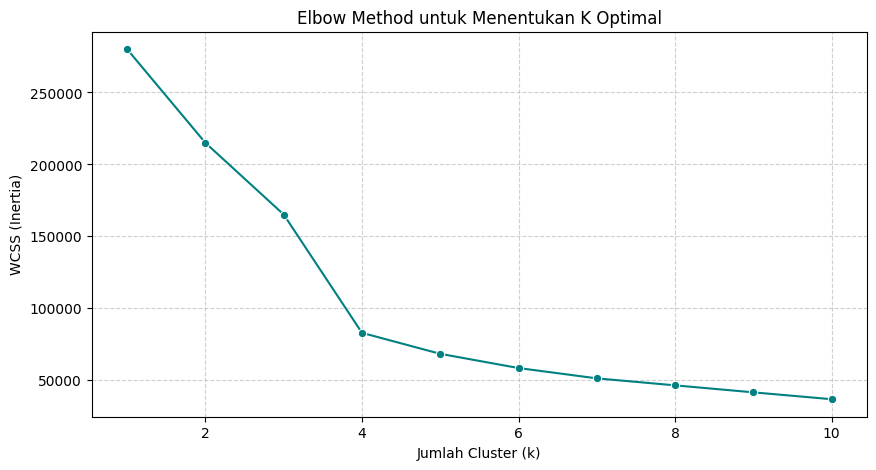

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# List untuk menampung nilai WCSS (Within-Cluster Sum of Squares)
wcss = []

# Mencoba k dari 1 sampai 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Visualisasi
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='teal')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

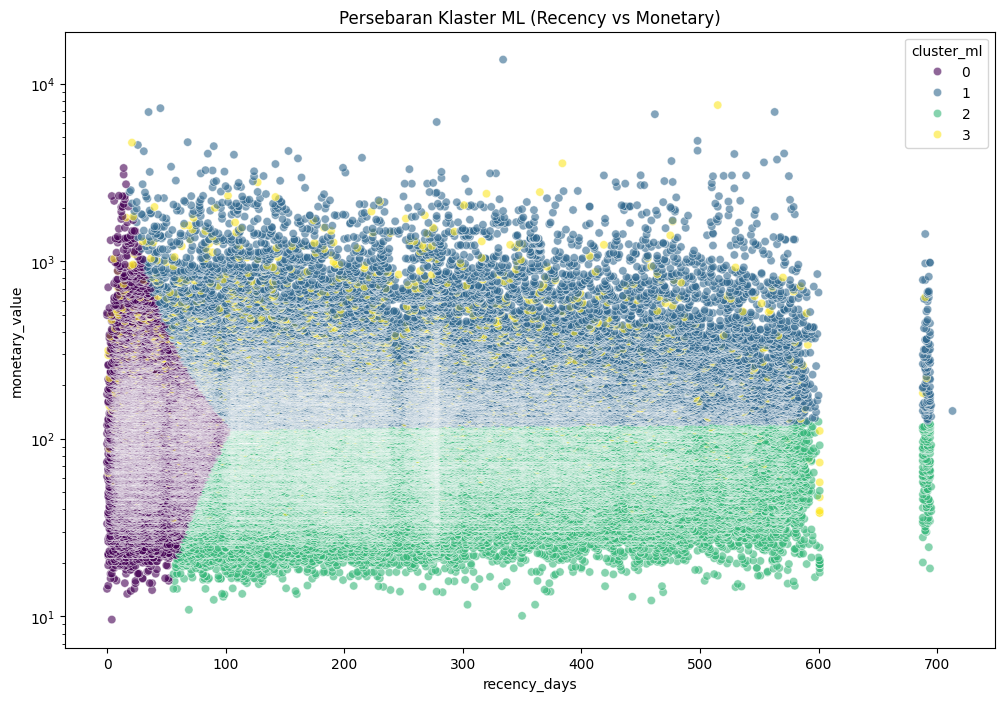

In [4]:
# 1. Menjalankan K-Means dengan k=4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['cluster_ml'] = kmeans.fit_transform(df_scaled).argmin(axis=1) # Mengambil indeks klaster

# 2. Visualisasi 3D atau Pairplot untuk melihat persebaran
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='recency_days', 
    y='monetary_value', 
    hue='cluster_ml', 
    palette='viridis',
    alpha=0.6
)
plt.yscale('log') # Gunakan skala log agar Monetary yang jutaan terlihat jelas
plt.title('Persebaran Klaster ML (Recency vs Monetary)')
plt.show()

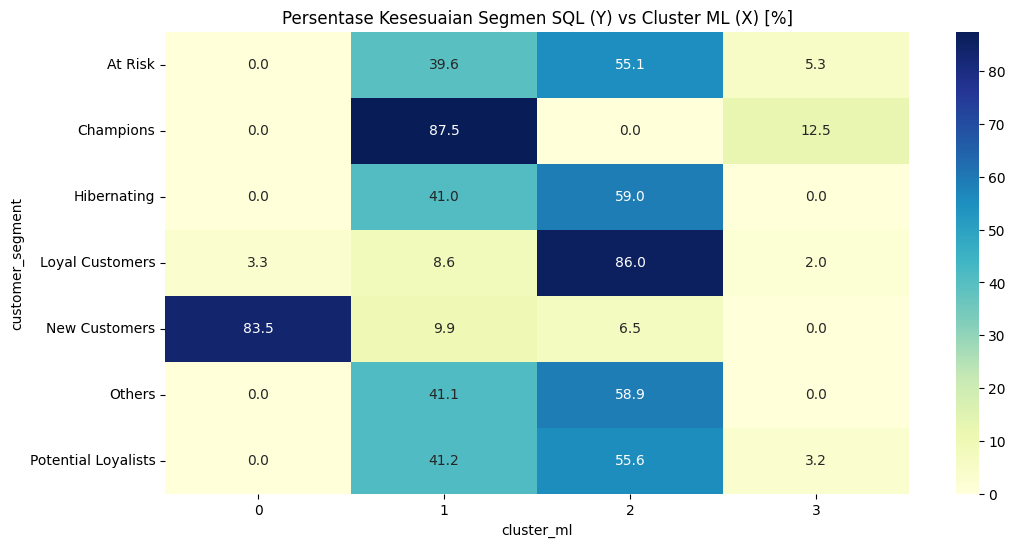

In [5]:
# Melihat perbandingan Label SQL vs Cluster ML
comparison = pd.crosstab(df['customer_segment'], df['cluster_ml'], normalize='index') * 100
plt.figure(figsize=(12, 6))
sns.heatmap(comparison, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Persentase Kesesuaian Segmen SQL (Y) vs Cluster ML (X) [%]')
plt.show()